In [12]:
%matplotlib inline
%matplotlib widget
%load_ext autoreload
%autoreload 2
import sys
import datetime as dt
import numpy as np
import netCDF4
import matplotlib
#matplotlib.use("Agg")  # need to set matplotlib backend manually
import matplotlib.pyplot as plt
import cmocean
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.transforms import offset_copy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from roppy import SGrid

In [15]:

roms1 = xr.open_dataset('https://thredds.met.no/thredds/dodsC/fou-hi/norkystv3_800m_m00_be', decode_cf=False)


/modules/rhel8/conda/install/envs/production-08-2024/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [34]:
roms2 = xr.open_dataset('https://thredds.met.no/thredds/dodsC/fou-hi/norkystv3_160m_m70_be', decode_cf=False)


In [35]:
roms2

<xarray.Dataset> Size: 784GB
Dimensions:                  (depth: 15, X: 552, Y: 777, time: 8461)
Coordinates:
  * depth                    (depth) float64 120B 0.0 1.0 2.0 ... 200.0 300.0
  * X                        (X) float32 2kB 6.731e+05 6.733e+05 ... 7.613e+05
  * Y                        (Y) float32 3kB 4.795e+05 4.797e+05 ... 6.037e+05
  * time                     (time) float64 68kB 1.713e+09 ... 1.744e+09
Data variables: (12/14)
    projection_stere         int32 4B ...
    forecast_reference_time  float64 8B ...
    h                        (Y, X) float32 2MB ...
    lon                      (Y, X) float32 2MB ...
    lat                      (Y, X) float32 2MB ...
    zeta                     (time, Y, X) int16 7GB ...
    ...                       ...
    w                        (time, depth, Y, X) int16 109GB ...
    temperature              (time, depth, Y, X) int16 109GB ...
    salinity                 (time, depth, Y, X) int16 109GB ...
    AKs                      (time, depth, Y, X) float32 218GB ...
    Uwind_eastward           (time, Y, X) int16 7GB ...
    Vwind_northward          (time, Y, X) int16 7GB ...
Attributes: (12/37)
    id:                         5a24b1b8-bf5e-4391-b479-4669479502c2
    naming_authority:           no.met
    operational_status:         Operational
    iso_topic_category:         oceans
    activity_type:              Numerical Simulation
    keywords_vocabulary:        GCMDSK:GCMD Science Keywords:https://gcmd.ear...
    ...                         ...
    dataset_production_status:  In Work
    license:                    https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                      Norkyst - ROMS, 160m 24 hours ocean forecast,...
    summary:                    Norkyst-160m (Norwegian Coast 160m horizontal...
    title_no:                   24 timers prognoser fra havmodellen Norkyst-1...
    summary_no:                 NorKyst-160m (Norske kystområder med 160m hor...

In [32]:
scale        = 1.5
cmap         = [cmocean.cm.balance, cmocean.cm.balance]
ocean_color  = cmap[0](0.5)
proj         = ccrs.NorthPolarStereo(central_longitude=-10)
land_50m     = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                                    edgecolor = 'k',
                                                    facecolor = cfeature.COLORS['land'])
lat_min = 61.57343
lat_max = 62.78639
lon_min = 4.7153926
lon_max = 7.629031

In [31]:
def set_map(lon, lat, axes):
    for ax in axes:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], ccrs.PlateCarree())
        #ax.add_feature(ocean)
        ax.add_feature(land_50m, facecolor = 'burlywood', alpha = 0.75, zorder = 101)
        #ax.add_feature(cfeature.BORDERS, linestyle='-', alpha= 0.5)
        ax.gridlines(zorder=100)

In [39]:
t=0
speed = np.sqrt(roms.u_eastward[t,0]**2 + roms.v_northward[t,0]**2)

NameError: name 'cb' is not defined

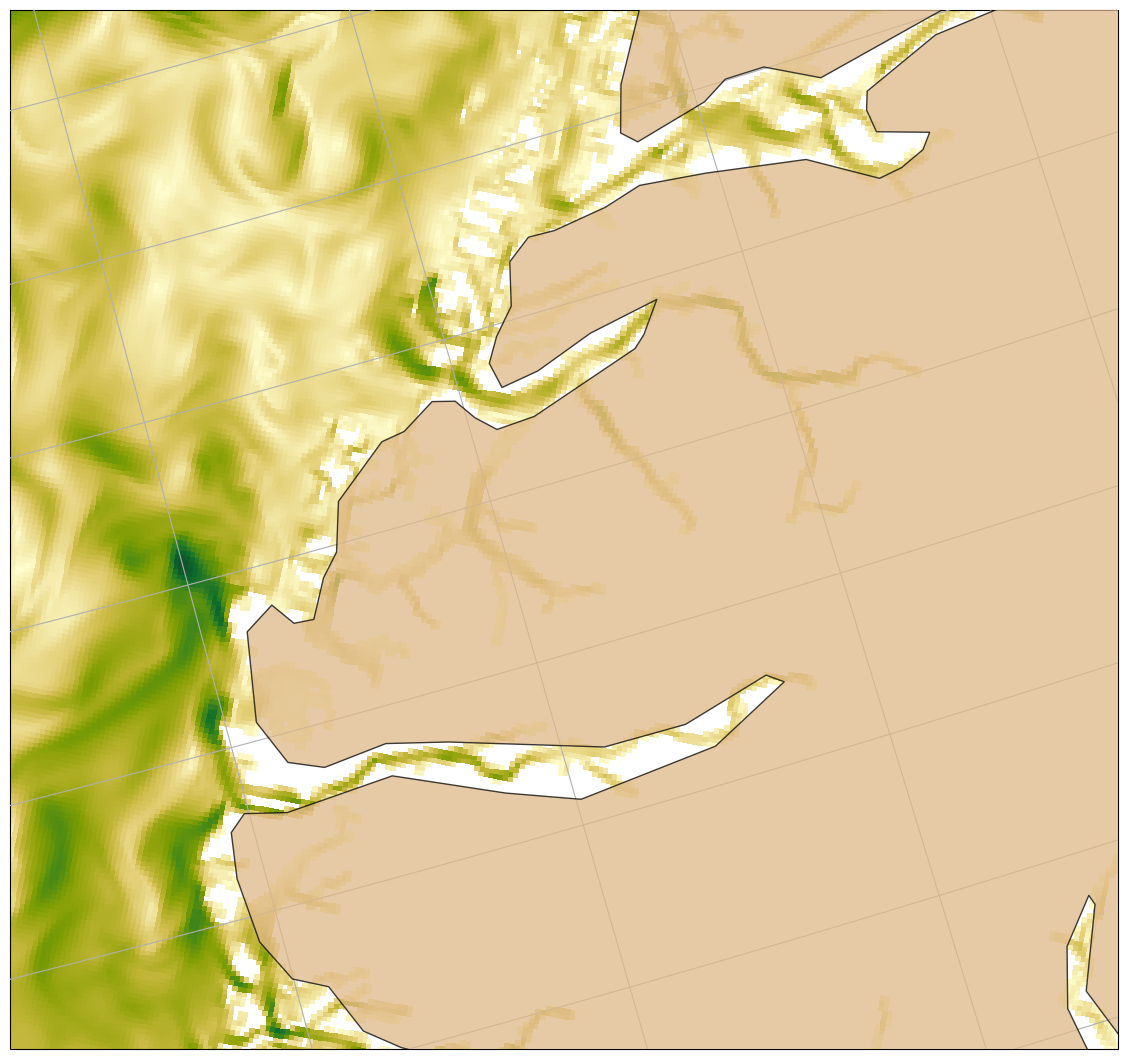

In [45]:
fig, ax      = plt.subplots(figsize = (16*scale,9*scale), subplot_kw = dict(projection = proj), ncols = 1 )



set_map(roms.lon, roms.lat, [ax])

cs_1 = ax.pcolormesh(roms.lon, roms.lat, speed, vmin = 0, vmax = 1., cmap=cmocean.cm.speed, transform=ccrs.PlateCarree())
#cb   = make_colorbar(ax[0],cs_1, orientation='horizontal')
cb.set_label(label="Speed [m/s]", fontsize=17)




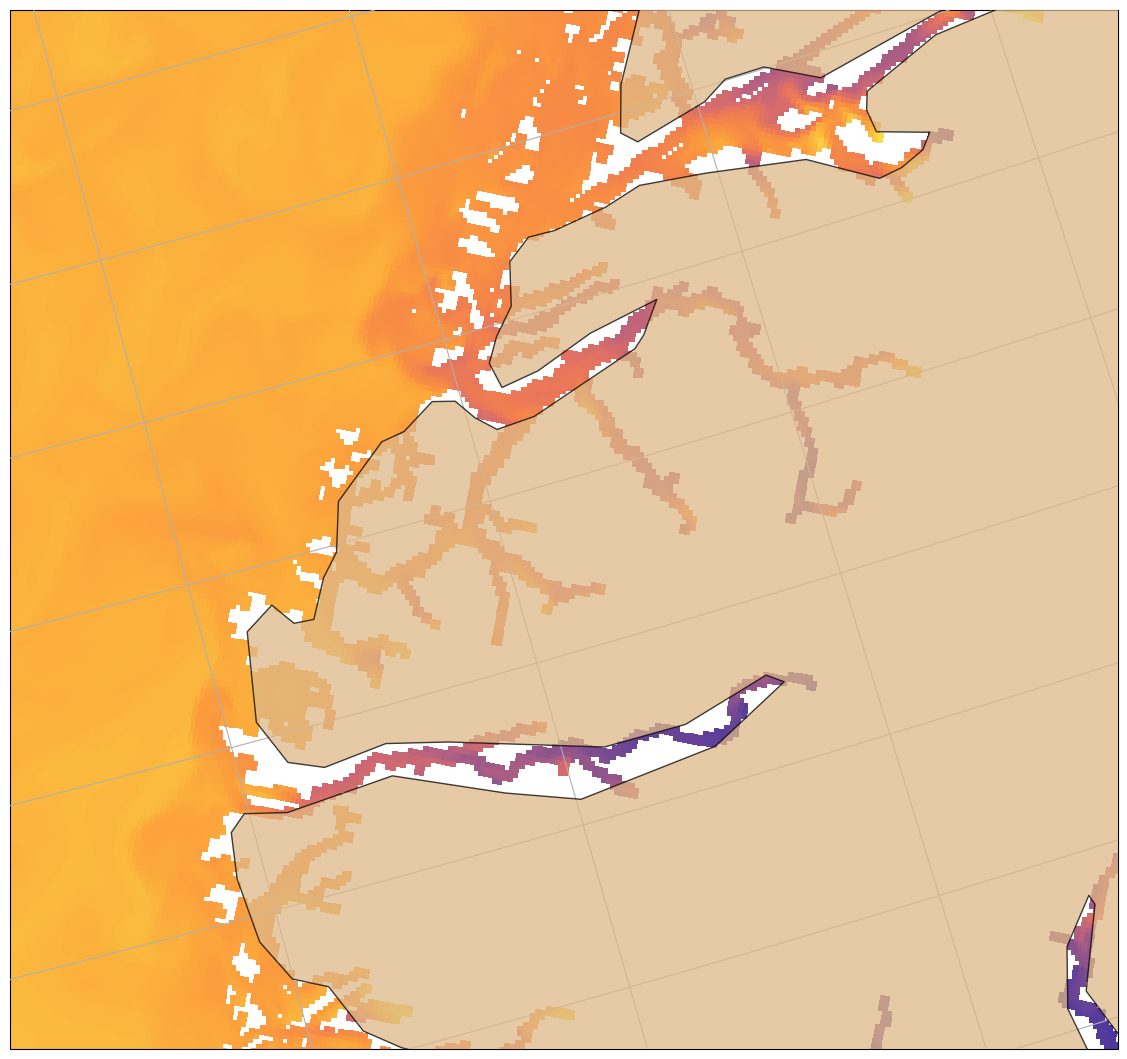

In [52]:
fig, ax      = plt.subplots(figsize = (16*scale,9*scale), subplot_kw = dict(projection = proj), ncols = 1 )

set_map(roms.lon, roms.lat, [ax])

cs_1 = ax.pcolormesh(roms.lon, roms.lat, roms.temperature[t,0], cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())
#cb   = make_colorbar(ax[0],cs_1, orientation='horizontal')
#cb.set_label(label="Speed [m/s]", fontsize=17)


